# Task 1 — Iris Dataset (EDA + Visualization)

## Goal
- Load `iris.csv` / `Iris.csv` (fallback to `seaborn.load_dataset("iris")` if missing)
- Perform EDA: `.head()`, `.info()`, `.describe()`
- Visualize:
  - Scatter: sepal length vs sepal width
  - Histograms: feature distributions
  - Box plots: outliers per feature


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

def find_first_existing(paths: list[Path]) -> Path | None:
    """Return the first path that exists, else None."""
    for p in paths:
        if p.exists() and p.is_file():
            return p
    return None

def load_iris_dataframe() -> pd.DataFrame:
    """Load iris data from CSV if available; otherwise fall back to seaborn."""
    here = Path.cwd()
    candidates = [
        here / "iris.csv",
        here / "Iris.csv",
        here.parent / "iris.csv",
        here.parent / "Iris.csv",
        here.parent.parent / "iris.csv",
        here.parent.parent / "Iris.csv",
    ]
    csv_path = find_first_existing(candidates)

    if csv_path is not None:
        df = pd.read_csv(csv_path)
        df["_source"] = f"csv:{csv_path}"
        return df

    df = sns.load_dataset("iris")
    df["_source"] = "seaborn:iris"
    return df

df_raw = load_iris_dataframe()
df_raw.shape, df_raw["_source"].iloc[0]

((150, 6), 'seaborn:iris')

## Column normalization
The local CSV and seaborn dataset use different column names. We normalize to:
- `sepal_length`, `sepal_width`, `petal_length`, `petal_width`, `species`


In [2]:
def normalize_iris_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Common Kaggle Iris CSV schema
    rename_map = {
        "SepalLengthCm": "sepal_length",
        "SepalWidthCm": "sepal_width",
        "PetalLengthCm": "petal_length",
        "PetalWidthCm": "petal_width",
        "Species": "species",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    # If seaborn naming is already present, keep it as-is.
    required = {"sepal_length", "sepal_width", "petal_length", "petal_width", "species"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(
            "Could not find required iris columns after normalization. "
            f"Missing: {sorted(missing)}. Columns present: {sorted(df.columns)}"
        )

    # Clean up optional columns
    if "Id" in df.columns:
        df = df.drop(columns=["Id"])

    # Standardize species labels (some CSVs use Iris-setosa etc.)
    df["species"] = df["species"].astype(str).str.replace("Iris-", "", regex=False)
    return df

df = normalize_iris_columns(df_raw)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,_source
0,5.1,3.5,1.4,0.2,setosa,seaborn:iris
1,4.9,3.0,1.4,0.2,setosa,seaborn:iris
2,4.7,3.2,1.3,0.2,setosa,seaborn:iris
3,4.6,3.1,1.5,0.2,setosa,seaborn:iris
4,5.0,3.6,1.4,0.2,setosa,seaborn:iris


## EDA (head/info/describe)
These are the core EDA checks required for the task.

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,_source
0,5.1,3.5,1.4,0.2,setosa,seaborn:iris
1,4.9,3.0,1.4,0.2,setosa,seaborn:iris
2,4.7,3.2,1.3,0.2,setosa,seaborn:iris
3,4.6,3.1,1.5,0.2,setosa,seaborn:iris
4,5.0,3.6,1.4,0.2,setosa,seaborn:iris


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
 5   _source       150 non-null    object 
dtypes: float64(4), object(2)
memory usage: 7.2+ KB


In [5]:
df.describe(include="all")

,sepal_length,sepal_width,petal_length,petal_width,species,_source
count,150.000000,150.000000,150.000000,150.000000,150,150
unique,NaN,NaN,NaN,NaN,3,1
top,NaN,NaN,NaN,NaN,setosa,seaborn:iris
freq,NaN,NaN,NaN,NaN,50,150
mean,5.843333,3.057333,3.758000,1.199333,NaN,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN,NaN


In [6]:
print("Missing values per column:")
display(df.isna().sum())

print("\nSpecies counts:")
display(df["species"].value_counts())

Missing values per column:


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0
_source,0



Species counts:


,count
species,
setosa,50
versicolor,50
virginica,50


## Visualizations
### 1) Scatter: Sepal Length vs Sepal Width
Color-coded by species to observe class separability.

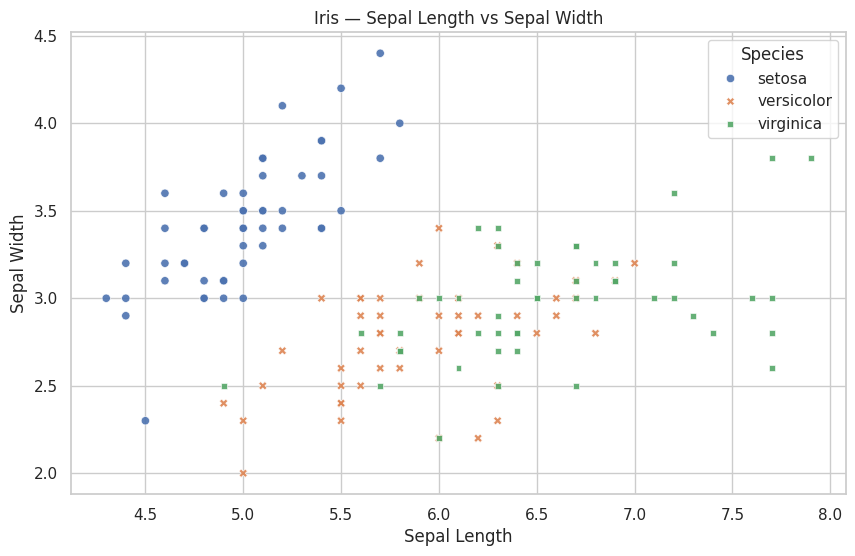

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="sepal_length",
    y="sepal_width",
    hue="species",
    style="species",
    alpha=0.9,
)
plt.title("Iris — Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend(title="Species")
plt.show()

### 2) Histograms: Feature Distributions
We plot per-feature distributions (optionally with KDE) to understand spread and overlap.

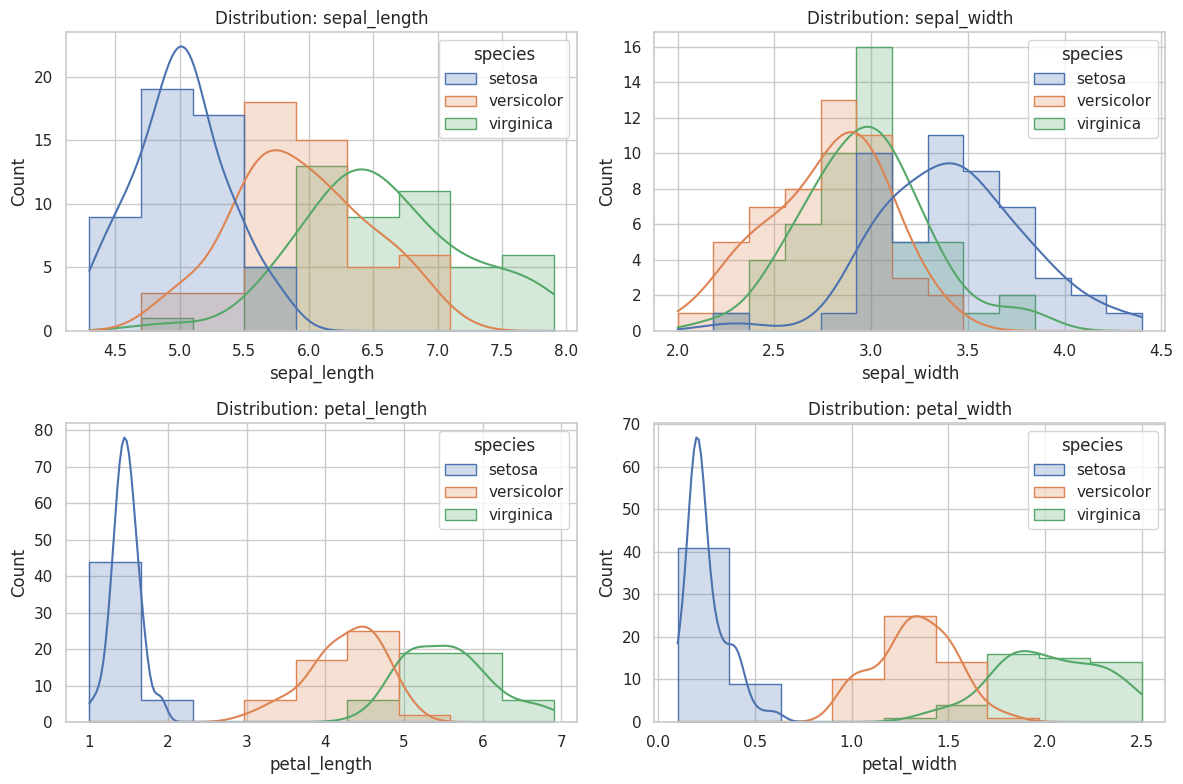

In [8]:
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, feature_cols):
    sns.histplot(data=df, x=col, hue="species", kde=True, element="step", ax=ax)
    ax.set_title(f"Distribution: {col}")

plt.tight_layout()
plt.show()

### 3) Box Plots: Outlier Inspection
Box plots per species highlight potential outliers and interquartile ranges.

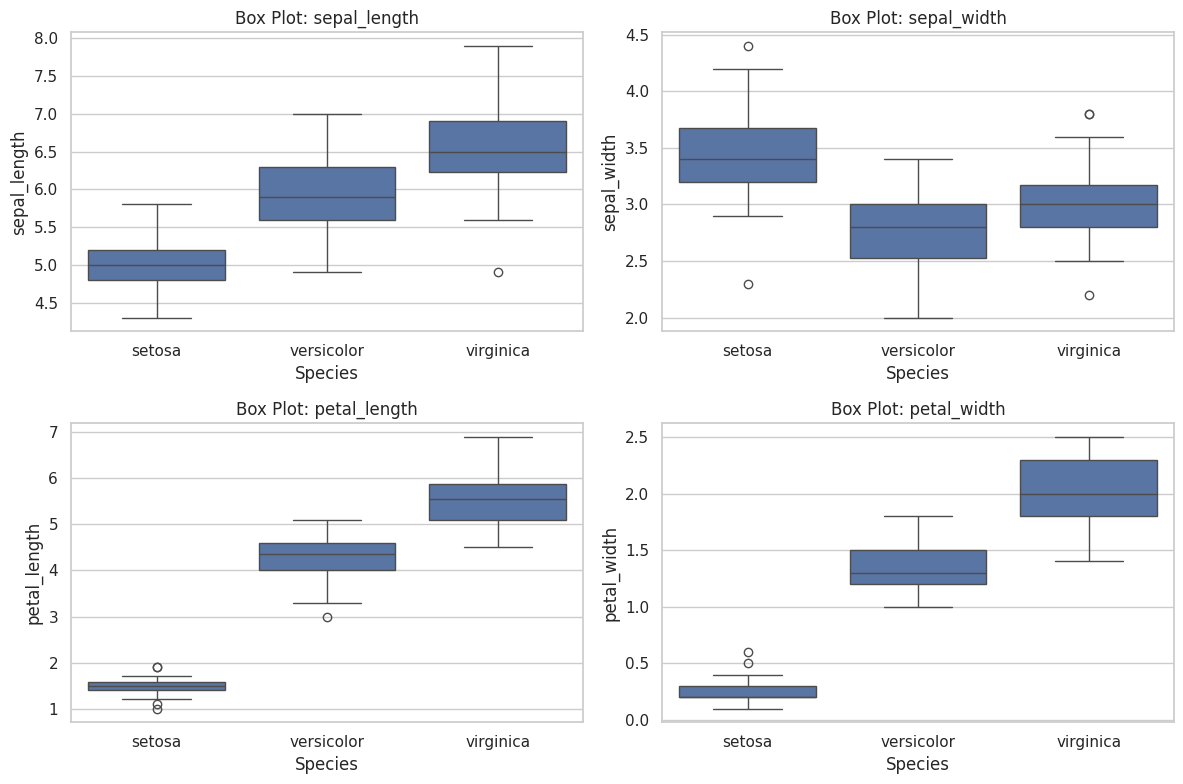

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, feature_cols):
    sns.boxplot(data=df, x="species", y=col, ax=ax)
    ax.set_title(f"Box Plot: {col}")
    ax.set_xlabel("Species")

plt.tight_layout()
plt.show()

## Correlation Heatmap
A correlation heatmap helps spot strong linear relationships between features.

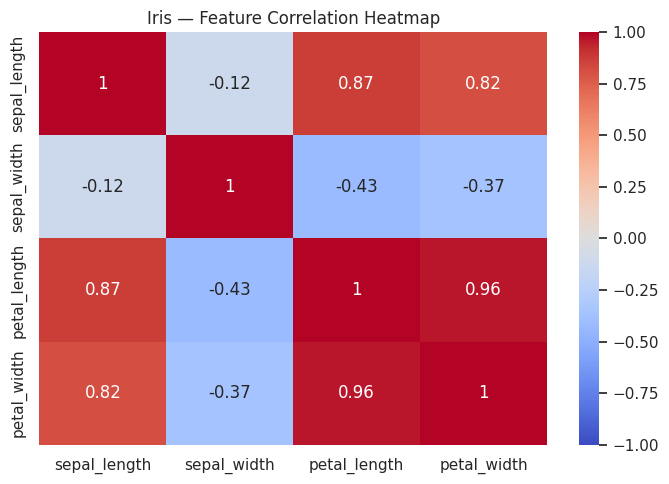

In [10]:
corr = df[feature_cols].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Iris — Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Pairplot
Pairplots visualize pairwise feature relationships and class separability.

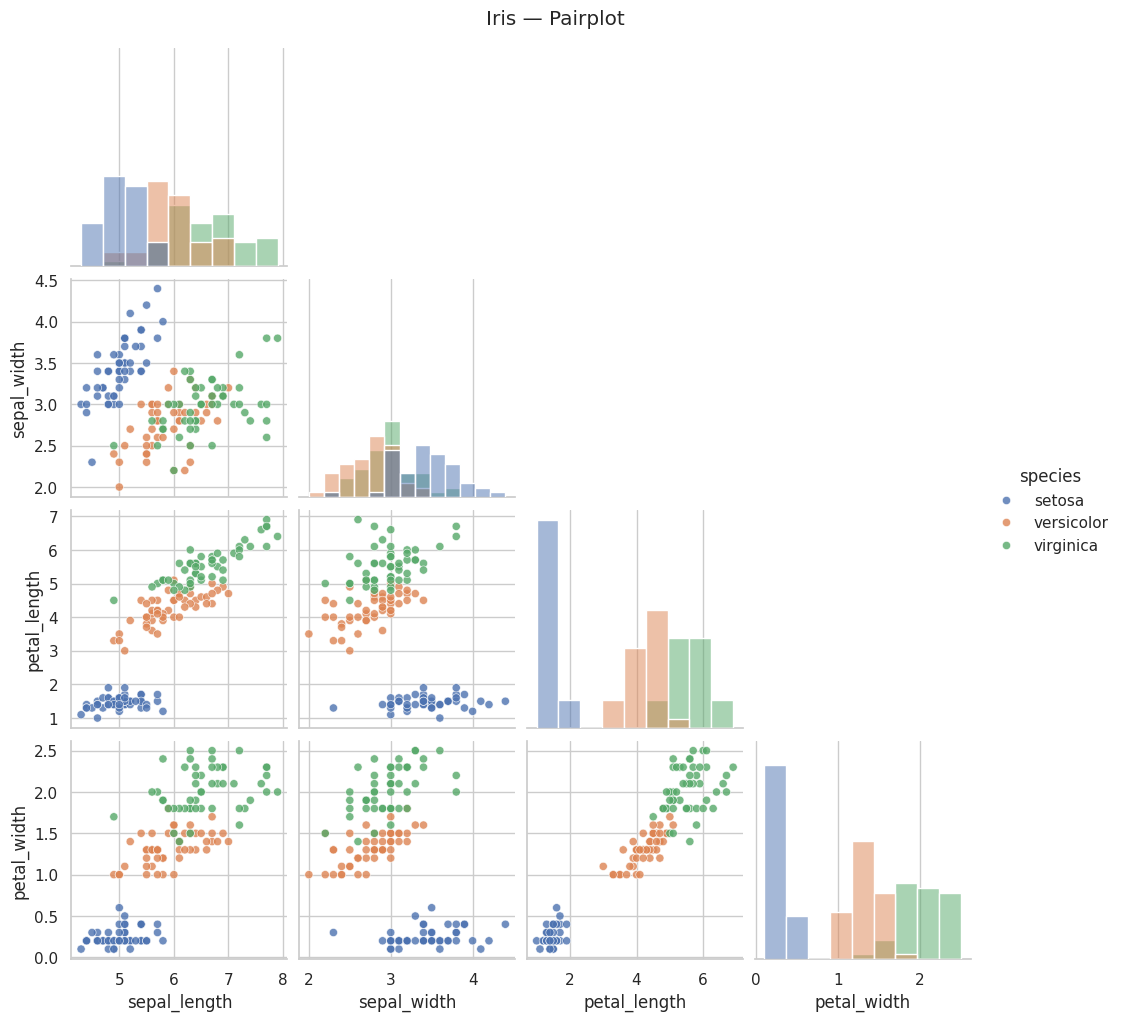

In [11]:
sns.pairplot(
    df,
    vars=feature_cols,
    hue="species",
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.8, "s": 35},
)
plt.suptitle("Iris — Pairplot", y=1.02)
plt.show()

## Simple Classifiers (Baseline)
This section adds a minimal classification workflow to complement the EDA.

We train a few simple models and compare their performance on a held-out test set.
To keep things fair:
- We use a stratified train/test split
- We scale features for models that benefit from it


In [13]:
from sklearn.model_selection import train_test_split

X = df[feature_cols].copy()
y = df["species"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train.shape, X_test.shape

((120, 4), (30, 4))

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]
    ),
    "KNN (k=5)": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5)),
        ]
    ),
    "SVM (RBF)": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", C=1.0, gamma="scale")),
        ]
    ),
}

results = []
preds_by_model = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    preds_by_model[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    results.append({"model": name, "accuracy": acc})

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
results_df

,model,accuracy
2,SVM (RBF),0.966667
0,Logistic Regression,0.933333
1,KNN (k=5),0.933333


Best model: SVM (RBF)
Accuracy: 0.9666666666666667

Classification report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



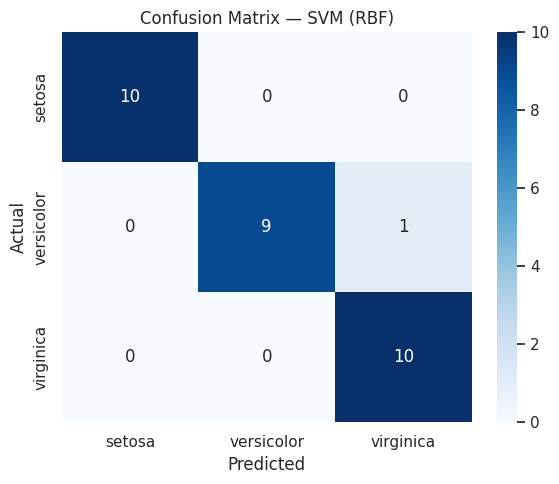

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Detailed evaluation for the best-performing model
best_model_name = results_df.iloc[0]["model"]
y_pred_best = preds_by_model[best_model_name]

print("Best model:", best_model_name)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best, labels=sorted(y.unique()))
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique()),
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()